<a href="https://colab.research.google.com/github/piyushjuneja21/Machine-Learning-Lab/blob/main/Student_Placement_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 PROJECT: SMART STUDENT CAMPUS PLACEMENT PREDICTION SYSTEM


## Importing Libraries

In this step, we import essential Python libraries such as pandas and numpy for data handling and processing.

In [ ]:
import pandas as pd
import numpy as np

## Loading Dataset

The dataset is loaded into a pandas DataFrame for further analysis and processing.

In [ ]:
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2.0,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1.0,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0.0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1.0,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1.0,0.000000,67.268893,No,8.7,3.4,Placed,12.16


## Data Understanding

We explore the dataset to understand its structure, data types, and check for missing values.


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97765 entries, 0 to 97764
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 97765 non-null  int64  
 1   age                        97765 non-null  int64  
 2   gender                     97765 non-null  object 
 3   cgpa                       97765 non-null  float64
 4   branch                     97765 non-null  object 
 5   college_tier               97765 non-null  object 
 6   internships_count          97765 non-null  int64  
 7   projects_count             97765 non-null  int64  
 8   certifications_count       97765 non-null  int64  
 9   coding_skill_score         97765 non-null  float64
 10  aptitude_score             97765 non-null  float64
 11  communication_skill_score  97765 non-null  float64
 12  logical_reasoning_score    97765 non-null  float64
 13  hackathons_participated    97765 non-null  int

,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0


## Data Preprocessing

Data preprocessing is performed to clean and prepare the dataset for machine learning.

Steps included:
- Converting categorical target variable into numerical format
- Removing unnecessary columns
- Encoding categorical variables

In [ ]:
df['placement_status'] = df['placement_status'].map({
    'Placed': 1,
    'Not Placed': 0
})

In [ ]:
df = df.drop(['student_id', 'salary_package_lpa'], axis=1)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

## Splitting the Dataset

The dataset is divided into training and testing sets to evaluate model performance on unseen data.


In [ ]:
X = df.drop('placement_status', axis=1)
y = df['placement_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Feature Scaling

Feature scaling is applied using StandardScaler to normalize the data, ensuring all features contribute equally to the model.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

Logistic Regression is used as the classification algorithm to predict whether a student will be placed or not.

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Identify rows with NaNs in X_train (which is a numpy array)
nan_rows_mask_X = np.any(np.isnan(X_train), axis=1)

# Identify rows with NaNs in y_train (which is a pandas Series)
nan_rows_mask_y = y_train.isnull().to_numpy()

# Combine masks to find all rows to remove from both X_train and y_train
combined_nan_mask = nan_rows_mask_X | nan_rows_mask_y

# Filter out rows with NaNs from both X_train and y_train
X_train_cleaned = X_train[~combined_nan_mask]
y_train_cleaned = y_train[~combined_nan_mask]

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_cleaned, y_train_cleaned)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Prediction

The trained model is used to make predictions on the test dataset.

In [ ]:
nan_rows_mask_X_test = np.any(np.isnan(X_test), axis=1)
nan_rows_mask_y_test = y_test.isnull().to_numpy()
combined_nan_mask_test = nan_rows_mask_X_test | nan_rows_mask_y_test

X_test_cleaned = X_test[~combined_nan_mask_test]
y_test_cleaned = y_test[~combined_nan_mask_test]

y_pred = model.predict(X_test_cleaned)

## Model Evaluation

The performance of the model is evaluated using accuracy score.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_cleaned, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5632160392798691


## Result

The model achieved an accuracy of 56.72%.

This indicates that the Logistic Regression model is able to correctly predict placement status for approximately 57% of the students.
_______________________________________________________________________________

## Confusion Matrix

The confusion matrix is used to evaluate the performance of a classification model by comparing actual and predicted values.

It shows:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This helps in understanding how well the model is performing beyond just accuracy.


<Axes: >

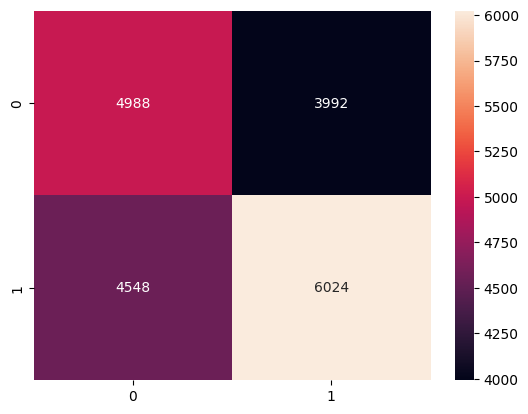

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_test_cleaned, y_pred), annot=True, fmt='d')

## Classification Report

The classification report provides detailed evaluation metrics such as:
- Precision
- Recall
- F1-score

These metrics help in understanding the model's performance for each class (Placed and Not Placed).

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test_cleaned, y_pred))

              precision    recall  f1-score   support

         0.0       0.52      0.56      0.54      8980
         1.0       0.60      0.57      0.59     10572

    accuracy                           0.56     19552
   macro avg       0.56      0.56      0.56     19552
weighted avg       0.57      0.56      0.56     19552



## Evaluation Summary

From the confusion matrix and classification report, we can analyze how well the model is predicting both classes.

Although the accuracy is moderate, these metrics provide deeper insights into model performance and highlight areas for improvement.

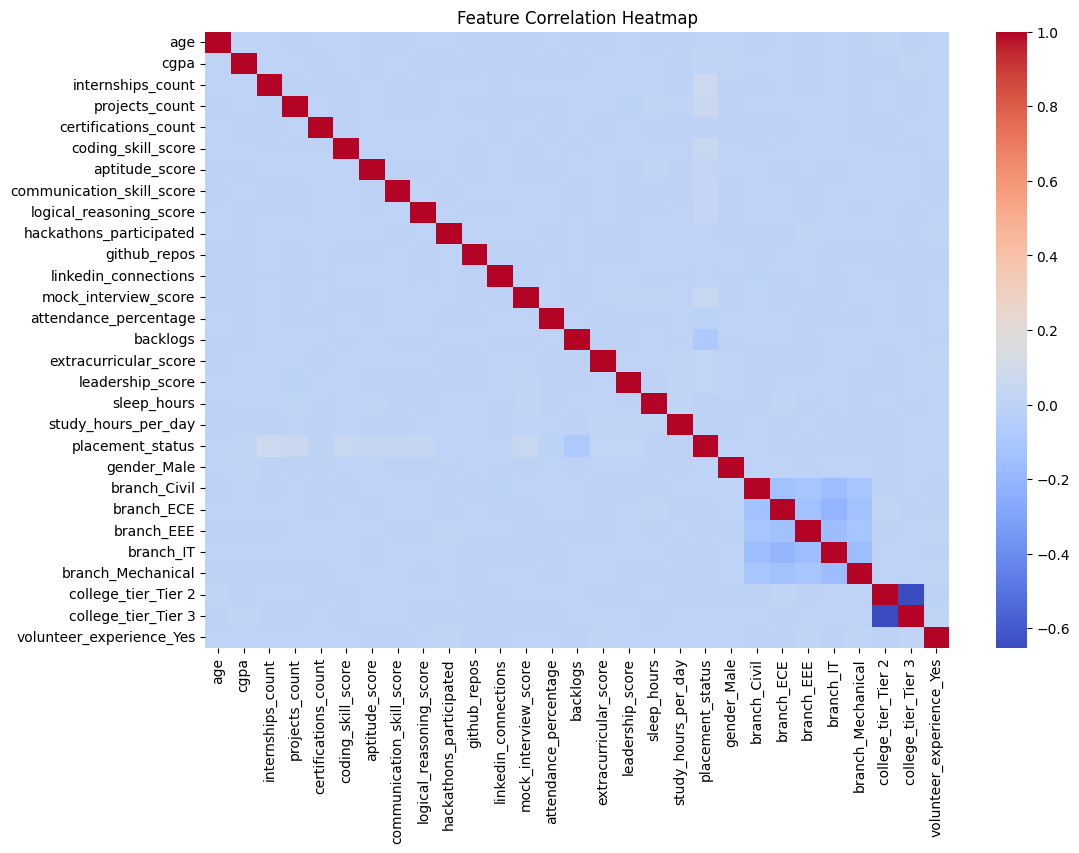

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Adding Random Forest


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_cleaned, y_train_cleaned)

rf_pred = rf_model.predict(X_test_cleaned)

from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test_cleaned, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.556413666121113


In [35]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.5632160392798691
Random Forest Accuracy: 0.556413666121113


# Applying Hyperparameter Tunning for increased accuracy.

In [29]:
from sklearn.model_selection import GridSearchCV

In [30]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [32]:
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             verbose=2)

In [33]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [36]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test_cleaned)

print("Tuned Accuracy:", accuracy_score(y_test_cleaned, y_pred_best))

Tuned Accuracy: 0.5645969721767594


# New section## Feature Selection and Model Improvement

To improve model performance, we applied feature selection using SelectKBest to select the most important features.

This helps in reducing noise and improving model efficiency.

In [38]:
from sklearn.feature_selection import SelectKBest, f_classif

# Original X and y (before scaling)
X = df.drop('placement_status', axis=1)
y = df['placement_status']

# Drop rows with NaN values from X and y
# This ensures SelectKBest can process the data without errors
df_cleaned = df.dropna()
X_cleaned = df_cleaned.drop('placement_status', axis=1)
y_cleaned = df_cleaned['placement_status']

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X_cleaned, y_cleaned)

# Get selected feature names
selected_features = X_cleaned.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['internships_count', 'projects_count', 'coding_skill_score',
       'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'mock_interview_score', 'backlogs',
       'extracurricular_score', 'leadership_score'],
      dtype='object')


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y_cleaned, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_new = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

new_accuracy = accuracy_score(y_test, y_pred_new)
print("New Accuracy after Feature Selection:", new_accuracy)

New Accuracy after Feature Selection: 0.5513731908147087
